In [1]:
import psycopg2
import pandas as pd
import networkx as nx
import base58
import matplotlib.pyplot as plt
import re
from math import comb
import matplotlib.dates as mdates
import networkx as nx
from collections import defaultdict
from networkx.algorithms.approximation.clique import large_clique_size
from itertools import combinations
import numpy as np
from networkx.algorithms.coloring import greedy_color
import random
from collections import Counter
import requests
import time
from datetime import datetime, timedelta, timezone

In [2]:
conn = psycopg2.connect(
    dbname="sui_indexer",
    user="postgres",
    password="56904628",
    host="172.26.112.1",
    port=5432
)
conn.autocommit = True
cur = conn.cursor()

In [3]:
cur.execute("""
SELECT
    t.checkpoint_sequence AS checkpoint,
    oc.transaction_digest AS tx,
    oc.address AS object_address
FROM transactions t
JOIN object_changes oc
  ON oc.transaction_digest = t.transaction_digest
WHERE oc.change_type IS NOT NULL
ORDER BY t.checkpoint_sequence, oc.transaction_digest;
""")

parent = {}
size = {}

def add(x):
    if x not in parent:
        parent[x] = x
        size[x] = 1

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra = find(a)
    rb = find(b)
    if ra == rb:
        return
    if size[ra] < size[rb]:
        ra, rb = rb, ra
    parent[rb] = ra
    size[ra] += size[rb]

def process_checkpoint(tx_to_objs, writers_by_obj):
    conflicting_txs = set()
    for writers in writers_by_obj.values():
        if len(writers) >= 2:
            conflicting_txs.update(writers)

    for tx in conflicting_txs:
        objs = tx_to_objs[tx]
        if len(objs) < 2:
            continue

        objs = list(objs)
        first = objs[0]
        add(first)
        for obj in objs[1:]:
            add(obj)
            union(first, obj)

prev_cp = None
prev_tx = None
tx_objs = set()

tx_to_objs = {}
writers_by_obj = defaultdict(set)

while True:
    batch = cur.fetchmany(100000)
    if not batch:
        break

    for cp, tx, obj in batch:
        if prev_cp is None:
            prev_cp = cp
            prev_tx = tx

        if cp != prev_cp:
            if tx_objs:
                tx_to_objs[prev_tx] = tx_objs
            process_checkpoint(tx_to_objs, writers_by_obj)

            tx_to_objs = {}
            writers_by_obj = defaultdict(set)
            tx_objs = set()
            prev_cp = cp
            prev_tx = tx

        elif tx != prev_tx:
            tx_to_objs[prev_tx] = tx_objs
            tx_objs = set()
            prev_tx = tx

        tx_objs.add(obj)
        writers_by_obj[obj].add(tx)

if tx_objs:
    tx_to_objs[prev_tx] = tx_objs
if tx_to_objs:
    process_checkpoint(tx_to_objs, writers_by_obj)

groups = defaultdict(list)
for obj in parent:
    groups[find(obj)].append(obj.hex())

groups = dict(sorted(groups.items(), key=lambda kv: len(kv[1]), reverse=True))

print("num_groups =", len(groups))
print("top_10_group_sizes =", [len(g) for g in list(groups.values())[:10]])

num_groups = 6772
top_10_group_sizes = [1459405, 37766, 9204, 6780, 4501, 4247, 3840, 2562, 1495, 1042]


In [4]:
group_list = list(groups.values())

largest_group_size = len(group_list[0])
total_objects = sum(len(g) for g in group_list)

percentage = largest_group_size / total_objects * 100

print("Largest group size:", largest_group_size)
print("Total objects in all groups:", total_objects)
print(f"Largest group percentage: {percentage:.2f}%")

Largest group size: 1459405
Total objects in all groups: 1571882
Largest group percentage: 92.84%


In [8]:
DEEP_SUI   = "0xb663828d6217467c8a1838a03793da896cbe745b150ebd57d82f814ca579fc22"
DEEP_USDC  = "0xf948981b806057580f91622417534f491da5f61aeaf33d0ed8e69fd5691c95ce"
SUI_USDC   = "0xe05dafb5133bcffb8d59f4e12465dc0e9faeaa05e3e342a08fe135800e3e4407"
BWETH_USDC = "0x1109352b9112717bd2a7c3eb9a416fff1ba6951760f5bdd5424cf5e4e5b3e65c"
WUSDC_USDC = "0xa0b9ebefb38c963fd115f52d71fa64501b79d1adcb5270563f92ce0442376545"
WUSDT_USDC = "0x4e2ca3988246e1d50b9bf209abb9c1cbfec65bd95afdacc620a36c67bdb8452f"
NS_SUI = "0x27c4fdb3b846aa3ae4a65ef5127a309aa3c1f466671471a806d8912a18b253e8"
NS_USDC = "0x0c0fdd4008740d81a8a7d4281322aee71a1b62c449eb5b142656753d89ebc060"
TYPUS_SUI = "0xe8e56f377ab5a261449b92ac42c8ddaacd5671e9fec2179d7933dd1a91200eec"
SUI_AUSD = "0x183df694ebc852a5f90a959f0f563b82ac9691e42357e9a9fe961d71a1b809c8"
AUSD_USDC = "0x5661fc7f88fbeb8cb881150a810758cf13700bb4e1f31274a244581b37c303c3"
DRF_SUI = "0x126865a0197d6ab44bfd15fd052da6db92fd2eb831ff9663451bbfa1219e2af2"
SEND_USDC = "0x1fe7b99c28ded39774f37327b509d58e2be7fff94899c06d22b407496a6fa990"
WAL_USDC = "0x56a1c985c1f1123181d6b881714793689321ba24301b3585eec427436eb1c76d"
WAL_SUI = "0x81f5339934c83ea19dd6bcc75c52e83509629a5f71d3257428c2ce47cc94d08b"
XBTC_USDC = "0x20b9a3ec7a02d4f344aa1ebc5774b7b0ccafa9a5d76230662fdc0300bb215307"
IKA_USDC = "0xfa732993af2b60d04d7049511f801e79426b2b6a5103e22769c0cead982b0f47"
ALKIMI_SUI = "0x84752993c6dc6fce70e25ddeb4daddb6592d6b9b0912a0a91c07cfff5a721d89"
LZWBTC_USDC = "0xf5142aafa24866107df628bf92d0358c7da6acc46c2f10951690fd2b8570f117"
USDE_USDC = "0x0fac1cebf35bde899cd9ecdd4371e0e33f44ba83b8a2902d69186646afa3a94b"
SUI_USDE = "0x034f3a42e7348de2084406db7a725f9d9d132a56c68324713e6e623601fb4fd7"

targets = {
    "DEEP_SUI": DEEP_SUI,
    "DEEP_USDC": DEEP_USDC,
    "SUI_USDC": SUI_USDC,
    "BWETH_USDC": BWETH_USDC,
    "WUSDC_USDC": WUSDC_USDC,
    "WUSDT_USDC" : WUSDT_USDC,
    "NS_SUI" : NS_SUI,
    "NS_USDC" : NS_USDC,
    "TYPUS_SUI" : TYPUS_SUI,
    "SUI_AUSD" : SUI_AUSD,
    "AUSD_USDC" : AUSD_USDC,
    "DRF_SUI" : DRF_SUI,
    "SEND_USDC" : SEND_USDC,
    "WAL_USDC" : WAL_USDC,
    "WAL_SUI" : WAL_SUI,
    "XBTC_USDC" : XBTC_USDC,
    "IKA_USDC" : IKA_USDC,
    "ALKIMI_SUI" : ALKIMI_SUI,
    "LZWBTC_USDC" : LZWBTC_USDC,
    "USDE_USDC" : USDE_USDC,
    "SUI_USDE" : SUI_USDE
}

largest_group = set(next(iter(groups.values())))

def normalize_addr(x):
    return x.lower().removeprefix("0x")

# check if objects in the largest object group
for name, obj in targets.items():
    norm_obj = normalize_addr(obj)
    print(f"{name}: {norm_obj in largest_group}")

DEEP_SUI: True
DEEP_USDC: True
SUI_USDC: True
BWETH_USDC: True
WUSDC_USDC: True
WUSDT_USDC: True
NS_SUI: True
NS_USDC: True
TYPUS_SUI: True
SUI_AUSD: True
AUSD_USDC: True
DRF_SUI: True
SEND_USDC: True
WAL_USDC: True
WAL_SUI: True
XBTC_USDC: True
IKA_USDC: True
ALKIMI_SUI: True
LZWBTC_USDC: False
USDE_USDC: False
SUI_USDE: False


In [9]:
# build reverse lookup: object -> group index
obj_to_group_idx = {}
for idx, group in enumerate(groups.values(), start=1):
    for obj in group:
        obj_to_group_idx[obj] = idx

print("\nGroup index for each object:")

for name, obj in targets.items():
    norm_obj = normalize_addr(obj)

    if norm_obj in obj_to_group_idx:
        print(f"{name}: group #{obj_to_group_idx[norm_obj]}")
    else:
        print(f"{name}: NOT FOUND")


Group index for each object:
DEEP_SUI: group #1
DEEP_USDC: group #1
SUI_USDC: group #1
BWETH_USDC: group #1
WUSDC_USDC: group #1
WUSDT_USDC: group #1
NS_SUI: group #1
NS_USDC: group #1
TYPUS_SUI: group #1
SUI_AUSD: group #1
AUSD_USDC: group #1
DRF_SUI: group #1
SEND_USDC: group #1
WAL_USDC: group #1
WAL_SUI: group #1
XBTC_USDC: group #1
IKA_USDC: group #1
ALKIMI_SUI: group #1
LZWBTC_USDC: NOT FOUND
USDE_USDC: NOT FOUND
SUI_USDE: NOT FOUND


In [4]:
cur.execute("""
SELECT
    t.checkpoint_sequence AS checkpoint,
    oc.transaction_digest AS tx,
    oc.address AS object_address,
    c.timestamp AS timestamp
FROM transactions t
JOIN object_changes oc
  ON oc.transaction_digest = t.transaction_digest
JOIN checkpoints c
  ON c.sequence_number = t.checkpoint_sequence
WHERE oc.change_type IS NOT NULL;
""")
write_rows = cur.fetchall()

In [24]:
largest_group_objects = set(next(iter(groups.values())))

graphs_largest = {}
graphs_without_largest = {}

timestamps_largest_by_cp = {}
timestamps_without_by_cp = {}

# current tx tracking
prev_cp = None
prev_tx = None
prev_timestamp = None
tx_objs = set()

# current checkpoint accumulators
current_cp = None
writers_largest = defaultdict(set)   # object_hex -> set(tx_hex)
writers_without = defaultdict(set)   # object_hex -> set(tx_hex)
txs_largest = set()
txs_without = set()

def flush_tx_into_current_checkpoint(cp, tx, objs, timestamp):
    if tx is None or not objs:
        return

    tx_hex = tx.hex()
    in_largest = bool(objs & largest_group_objects)

    if in_largest:
        txs_largest.add(tx_hex)
        timestamps_largest_by_cp.setdefault(cp, timestamp)
        for obj_hex in objs:
            writers_largest[obj_hex].add(tx_hex)
    else:
        txs_without.add(tx_hex)
        timestamps_without_by_cp.setdefault(cp, timestamp)
        for obj_hex in objs:
            writers_without[obj_hex].add(tx_hex)

def flush_checkpoint(cp):
    if cp is None:
        return

    G1 = nx.Graph()
    G1.add_nodes_from(txs_largest)
    for writers in writers_largest.values():
        if len(writers) >= 2:
            for u, v in combinations(writers, 2):
                G1.add_edge(u, v)
    if len(G1) > 0:
        graphs_largest[cp] = G1

    G2 = nx.Graph()
    G2.add_nodes_from(txs_without)
    for writers in writers_without.values():
        if len(writers) >= 2:
            for u, v in combinations(writers, 2):
                G2.add_edge(u, v)
    if len(G2) > 0:
        graphs_without_largest[cp] = G2

    writers_largest.clear()
    writers_without.clear()
    txs_largest.clear()
    txs_without.clear()

for checkpoint, tx, object_address, timestamp in write_rows:
    if prev_cp is None:
        prev_cp = checkpoint
        prev_tx = tx
        prev_timestamp = timestamp
        current_cp = checkpoint

    # new tx
    if checkpoint != prev_cp or tx != prev_tx:
        flush_tx_into_current_checkpoint(prev_cp, prev_tx, tx_objs, prev_timestamp)
        tx_objs.clear()

        # new checkpoint
        if checkpoint != prev_cp:
            flush_checkpoint(prev_cp)
            current_cp = checkpoint

        prev_cp = checkpoint
        prev_tx = tx
        prev_timestamp = timestamp

    tx_objs.add(object_address.hex())

# flush final tx and final checkpoint
flush_tx_into_current_checkpoint(prev_cp, prev_tx, tx_objs, prev_timestamp)
flush_checkpoint(prev_cp)

print(f"Built {len(graphs_largest)} largest-group checkpoint graphs")
print(f"Built {len(graphs_without_largest)} without-largest checkpoint graphs")

Built 63898 largest-group checkpoint graphs
Built 73190 without-largest checkpoint graphs


Total 73191 concurrent access graphs

the largest object group dominates the object space appearing in the dataset, but transactions interacting with these objects do not dominate the transaction workload.

In [25]:
rows_with = []
rows_without = []

for cp, G in graphs_largest.items():
    rows_with.append({
        "checkpoint": cp,
        "density": nx.density(G),
        "timestamp": timestamps_largest_by_cp[cp]
    })

for cp, G in graphs_without_largest.items():
    rows_without.append({
        "checkpoint": cp,
        "density": nx.density(G),
        "timestamp": timestamps_without_by_cp[cp]
    })

df_density_with = pd.DataFrame(rows_with).set_index("checkpoint")
df_density_without = pd.DataFrame(rows_without).set_index("checkpoint")

In [26]:
largest_cc_with = {}
largest_cc_without = {}

for cp, G in graphs_largest.items():
    if G.number_of_nodes() == 0:
        continue
    largest_cc_with[cp] = len(max(nx.connected_components(G), key=len))

for cp, G in graphs_without_largest.items():
    if G.number_of_nodes() == 0:
        continue
    largest_cc_without[cp] = len(max(nx.connected_components(G), key=len))

C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_8836\972961338.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_with = df_merge_with.groupby("density_bin")["largest_cc"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_8836\972961338.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers_with = df_merge_with.groupby("density_bin")["density"].mean()
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_8836\972961338.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or o

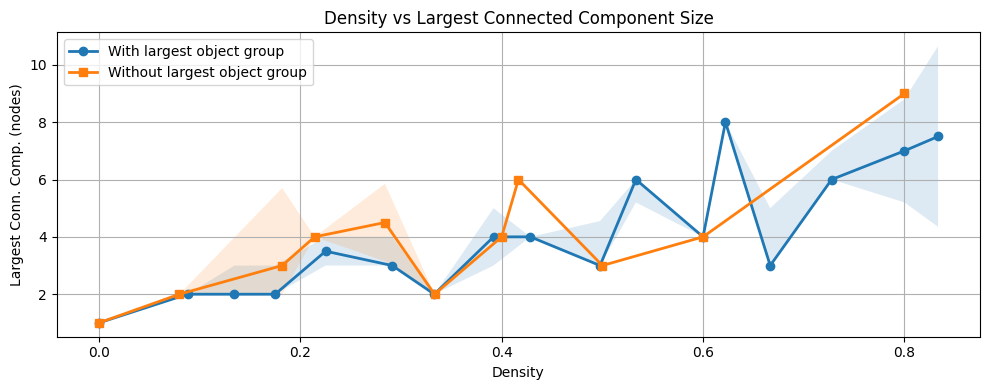

In [27]:
df_lcc_with = pd.DataFrame(
    [
        (cp, lcc, timestamps_largest_by_cp[cp])
        for cp, lcc in largest_cc_with.items()
    ],
    columns=["checkpoint", "largest_cc", "timestamp"]
)

df_lcc_without = pd.DataFrame(
    [
        (cp, lcc, timestamps_without_by_cp[cp])
        for cp, lcc in largest_cc_without.items()
    ],
    columns=["checkpoint", "largest_cc", "timestamp"]
)

df_lcc_with["timestamp"] = pd.to_datetime(df_lcc_with["timestamp"], utc=True)
df_lcc_without["timestamp"] = pd.to_datetime(df_lcc_without["timestamp"], utc=True)

df_merge_with = (
    df_density_with.reset_index()
    .merge(df_lcc_with, on="checkpoint", how="inner")
)

df_merge_without = (
    df_density_without.reset_index()
    .merge(df_lcc_without, on="checkpoint", how="inner")
)

df_merge_with["density_bin"] = pd.cut(df_merge_with["density"], bins=20)
df_merge_without["density_bin"] = pd.cut(df_merge_without["density"], bins=20)

df_merge_with = df_merge_with[df_merge_with["density"] < 0.95]
df_merge_without = df_merge_without[df_merge_without["density"] < 0.95]

plt.figure(figsize=(10, 4))

stats_with = df_merge_with.groupby("density_bin")["largest_cc"].agg(
    median="median",
    p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
    p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
)
centers_with = df_merge_with.groupby("density_bin")["density"].mean()
stats_with = stats_with.reindex(centers_with.index)
mask_with = ~stats_with["median"].isna()
stats_with = stats_with[mask_with]
centers_with = centers_with[mask_with]

plt.fill_between(
    centers_with,
    stats_with["p5"],
    stats_with["p95"],
    alpha=0.15,
)
plt.plot(
    centers_with,
    stats_with["median"],
    marker="o",
    linewidth=2,
    label="With largest object group",
)

stats_without = df_merge_without.groupby("density_bin")["largest_cc"].agg(
    median="median",
    p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
    p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
)
centers_without = df_merge_without.groupby("density_bin")["density"].mean()
stats_without = stats_without.reindex(centers_without.index)
mask_without = ~stats_without["median"].isna()
stats_without = stats_without[mask_without]
centers_without = centers_without[mask_without]

plt.fill_between(
    centers_without,
    stats_without["p5"],
    stats_without["p95"],
    alpha=0.15,
)
plt.plot(
    centers_without,
    stats_without["median"],
    marker="s",
    linewidth=2,
    label="Without largest object group",
)

plt.xlabel("Density")
plt.ylabel("Largest Conn. Comp. (nodes)")
plt.title("Density vs Largest Connected Component Size")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

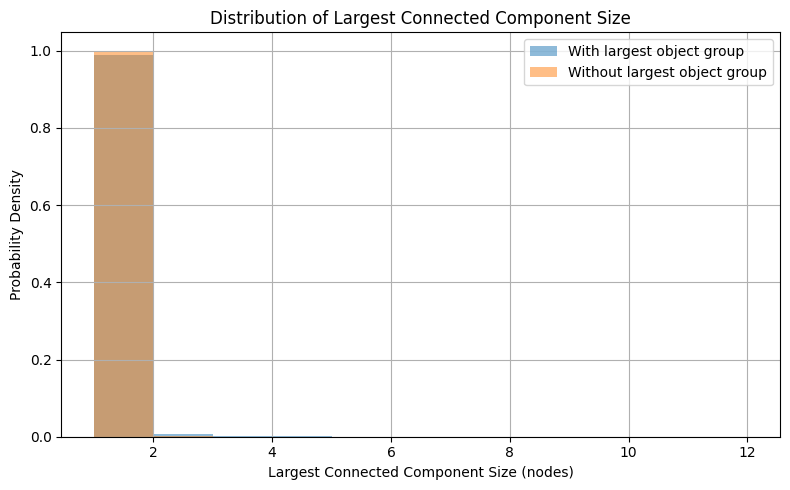

In [16]:
plt.figure(figsize=(8,5))

bins = np.arange(
    min(df_merge_with["largest_cc"].min(),
        df_merge_without["largest_cc"].min()),
    max(df_merge_with["largest_cc"].max(),
        df_merge_without["largest_cc"].max()) + 2
)

plt.hist(
    df_merge_with["largest_cc"],
    bins=bins,
    alpha=0.5,
    density=True,
    label="With largest object group",
)

plt.hist(
    df_merge_without["largest_cc"],
    bins=bins,
    alpha=0.5,
    density=True,
    label="Without largest object group",
)

plt.xlabel("Largest Connected Component Size (nodes)")
plt.ylabel("Probability Density")
plt.title("Distribution of Largest Connected Component Size")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

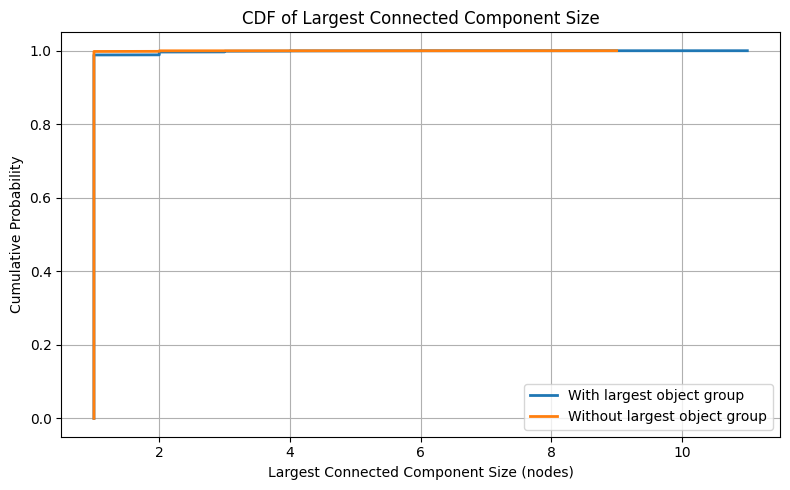

In [19]:
plt.figure(figsize=(8,5))

# sort values
with_vals = np.sort(df_merge_with["largest_cc"])
without_vals = np.sort(df_merge_without["largest_cc"])

# compute CDF
cdf_with = np.arange(1, len(with_vals)+1) / len(with_vals)
cdf_without = np.arange(1, len(without_vals)+1) / len(without_vals)

plt.plot(
    with_vals,
    cdf_with,
    linewidth=2,
    label="With largest object group"
)

plt.plot(
    without_vals,
    cdf_without,
    linewidth=2,
    label="Without largest object group"
)

plt.xlabel("Largest Connected Component Size (nodes)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Largest Connected Component Size")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
def greedy_long_path_len(C):
    start = max(C.degree, key=lambda x: x[1])[0]
    visited = {start}
    cur = start
    length = 0
    while True:
        nxts = [v for v in C.neighbors(cur) if v not in visited]
        if not nxts:
            break
        cur = min(nxts, key=lambda v: C.degree[v])
        visited.add(cur)
        length += 1
    return length

In [11]:
longest_simple_path_with = {}
longest_simple_path_without = {}

for cp, G in graphs_largest.items():
    length = greedy_long_path_len(G)
    longest_simple_path_with[cp] = length

for cp, G in graphs_without_largest.items():
    length = greedy_long_path_len(G)
    longest_simple_path_without[cp] = length

C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_8836\3076434038.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_with = df_merge_with_path.groupby("density_bin")["longest_path"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_8836\3076434038.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers_with = df_merge_with_path.groupby("density_bin")["density"].mean()
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_8836\3076434038.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curren

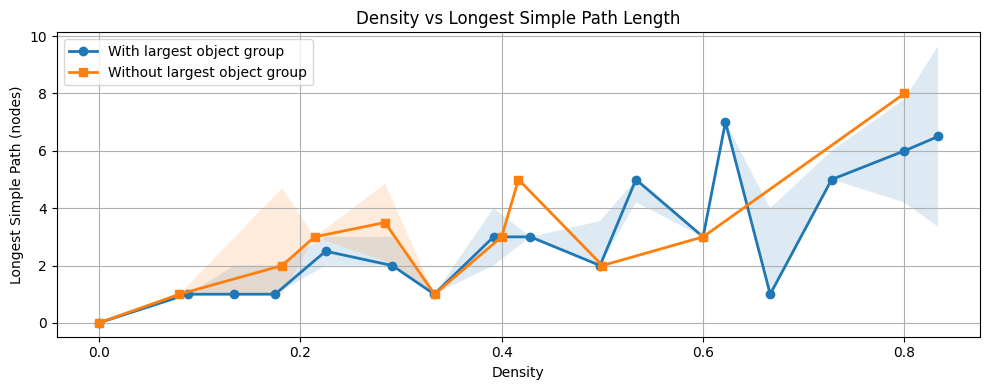

In [15]:
df_path_with = pd.DataFrame(
    [
        (cp, path_len, timestamps_largest_by_cp[cp])
        for cp, path_len in longest_simple_path_with.items()
    ],
    columns=["checkpoint", "longest_path", "timestamp"]
)

df_path_without = pd.DataFrame(
    [
        (cp, path_len, timestamps_without_by_cp[cp])
        for cp, path_len in longest_simple_path_without.items()
    ],
    columns=["checkpoint", "longest_path", "timestamp"]
)

df_path_with["timestamp"] = pd.to_datetime(df_path_with["timestamp"], utc=True)
df_path_without["timestamp"] = pd.to_datetime(df_path_without["timestamp"], utc=True)

df_merge_with_path = (
    df_density_with.reset_index()
    .merge(df_path_with, on="checkpoint", how="inner")
)

df_merge_without_path = (
    df_density_without.reset_index()
    .merge(df_path_without, on="checkpoint", how="inner")
)

df_merge_with_path["density_bin"] = pd.cut(df_merge_with_path["density"], bins=20)
df_merge_without_path["density_bin"] = pd.cut(df_merge_without_path["density"], bins=20)

df_merge_with_path = df_merge_with_path[df_merge_with_path["density"] < 0.95]
df_merge_without_path = df_merge_without_path[df_merge_without_path["density"] < 0.95]

plt.figure(figsize=(10, 4))

stats_with = df_merge_with_path.groupby("density_bin")["longest_path"].agg(
    median="median",
    p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
    p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
)
centers_with = df_merge_with_path.groupby("density_bin")["density"].mean()
stats_with = stats_with.reindex(centers_with.index)
mask_with = ~stats_with["median"].isna()
stats_with = stats_with[mask_with]
centers_with = centers_with[mask_with]

plt.fill_between(
    centers_with,
    stats_with["p5"],
    stats_with["p95"],
    alpha=0.15,
)
plt.plot(
    centers_with,
    stats_with["median"],
    marker="o",
    linewidth=2,
    label="With largest object group",
)

stats_without = df_merge_without_path.groupby("density_bin")["longest_path"].agg(
    median="median",
    p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
    p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
)
centers_without = df_merge_without_path.groupby("density_bin")["density"].mean()
stats_without = stats_without.reindex(centers_without.index)
mask_without = ~stats_without["median"].isna()
stats_without = stats_without[mask_without]
centers_without = centers_without[mask_without]

plt.fill_between(
    centers_without,
    stats_without["p5"],
    stats_without["p95"],
    alpha=0.15,
)
plt.plot(
    centers_without,
    stats_without["median"],
    marker="s",
    linewidth=2,
    label="Without largest object group",
)

plt.xlabel("Density")
plt.ylabel("Longest Simple Path (nodes)")
plt.title("Density vs Longest Simple Path Length")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()